In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
data = sns.load_dataset("tips")
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

Text(0, 0.5, 'tips')

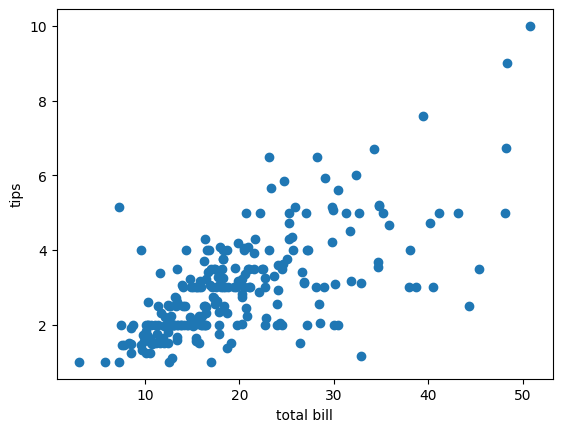

In [5]:
plt.scatter(data[['total_bill']],data['tip'])
plt.xlabel('total bill')
plt.ylabel('tips')

In [6]:
x,y =data[['total_bill']],data['tip']

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform (x_test)

#Train model
model = LinearRegression()
model.fit(x_train , y_train)
y_pred = model.predict(x_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test , y_pred)

rmse = np.sqrt(mean_squared_error(y_test , y_pred))

r2 = r2_score(y_test,y_pred)
adj_r2 = 1-(1-r2)*(len(y_test)-1)/(len(y_test)-2)

In [10]:
print("Model Evaluation\n")
print(f" mae:{mae}\n rmse:{rmse}\n r2_score:{r2}\n adj r2:{adj_r2}")

Model Evaluation

 mae:0.6208580000398983
 rmse:0.7541977545199626
 r2_score:0.5449381659234664
 adj r2:0.535255999240987


Text(0, 0.5, 'Tip')

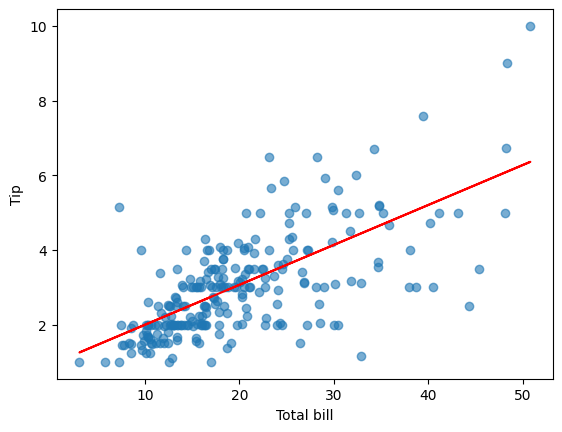

In [12]:
fig,ax=plt.subplots()
ax.scatter(data["total_bill"] , data["tip"] , alpha =0.6)
ax.plot(data["total_bill"] ,model.predict(scaler.transform(x)),color ="red" )
ax.set_xlabel("Total bill")
ax.set_ylabel("Tip")